In [58]:
import pandas as pd
from datetime import datetime
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
dir_path = "Churn Predict + RFM/"
transac_df = pd.read_csv(dir_path + "orders.csv")
customer_df = pd.read_csv(dir_path + "customers.csv")
product_df = pd.read_csv(dir_path + "product_summary.csv")

### Nous allons commencer notre traitement par les transactions et sur la base de celles ci ressortir le score RFM

In [5]:
RFM_base = transac_df[["order_id","customer_id","order_date","total_amount_usd"]]

In [6]:
RFM_base = RFM_base.drop_duplicates() #Cette partie vise a supplimer es doublons et ne rester qu'avec une seule transaction par ligne

In [7]:
RFM_base['order_date'] = pd.to_datetime(RFM_base['order_date'])
RFM_base.dtypes

order_id                    object
customer_id                 object
order_date          datetime64[ns]
total_amount_usd           float64
dtype: object

## Creation des valeurs agregees
  ### -> (R) Recence : nombre de jours qui s'est ecoule entre la derniere commande (MAX (oder_date)) et la date d'aujourd'hui
  ### -> (F) Frequence : nombre total de transactions realisees par le client (COUNT_DISTINCT(order_id))
  ### -> (M) Monnaie : Volume total des transactions realise par le client sur la periode cible. 
  

In [8]:
rfm = RFM_base.groupby("customer_id").agg({
    "order_date": lambda x: (pd.Timestamp.today() - x.max()).days,  # Recency
    "order_id": "count",                            # Frequency
    "total_amount_usd": "sum"                       # Monetary
}).reset_index()

rfm.columns = ["customer_id", "recency", "frequency", "monetary"]

In [54]:
rfm['R_score'] = pd.qcut(rfm['recency'], 5 , labels = ["Tres Actif", "Actif", "En PDV", "Inactif", "Perdu"])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method ='first'), 5, labels = ["Rare", "Occasionel", "Neutre", "Frequent", "Fidele"])
rfm['M_score'] = pd.qcut(rfm['monetary'], 5, labels=["faible", "Modere", "Bonne Valeur", "Haute Valeur", "Très haute valeur"])

In [55]:
rfm['R_num'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_num'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_num'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_score'] = rfm['R_num'] + rfm['F_num'] + rfm['M_num']

def segment(score):
    if score >= 13: return "Champion"
    elif score >= 10: return "Client Fidèle"
    elif score >= 7:  return "Client à Potentiel"
    elif score >= 4:  return "Client à Risque"
    else:             return "Client Perdu"

rfm['segment'] = rfm['RFM_score'].apply(segment)

In [56]:
rfm.to_csv('custmer_RFM.csv')

In [11]:
rfm['score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

## Nous avons nos segments avec de noms pour chaque segment. Par la suite nous allons :
### --> Croiser la frequence a la masse monetaire (F x M), le but est de voir si il y a une difference entre les clients recents et les clients effectant des operations rares.
### --> Croiser la recence a la masse monetaire (F x M), le but est de savoir si les achats les recents sont plus porteurs que les recents et ainsi identifier si nous sommes en hause ou alors en baisse de l'activite

In [16]:
Cash_per_Recency = rfm.groupby('R_score')['monetary'].sum().reset_index()
Cash_per_Recency['monetary_repartition'] = Cash_per_Recency['monetary'] / Cash_per_Recency['monetary'].sum() * 100
Cash_per_Recency

C:\Users\HP\AppData\Local\Temp\ipykernel_2992\2688844441.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Cash_per_Recency = rfm.groupby('R_score')['monetary'].sum().reset_index()


,R_score,monetary,monetary_repartition
0,Tres Actif,759609.52,24.219117
1,Actif,738260.42,23.538430
2,En PDV,671701.37,21.416285
3,Inactif,567829.10,18.104459
4,Perdu,399004.25,12.721708


In [17]:
Cash_per_frequency = rfm.groupby('F_score')['monetary'].sum().reset_index()
Cash_per_frequency['monetary_repartition'] = Cash_per_frequency['monetary'] / Cash_per_frequency['monetary'].sum() * 100
Cash_per_frequency

C:\Users\HP\AppData\Local\Temp\ipykernel_2992\3686335871.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Cash_per_frequency = rfm.groupby('F_score')['monetary'].sum().reset_index()


,F_score,monetary,monetary_repartition
0,Rare,250718.85,7.993830
1,Occasionel,399939.14,12.751516
2,Neutre,593976.81,18.938143
3,Frequent,788400.88,25.137091
4,Fidele,1103368.98,35.179420


C:\Users\HP\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


<Axes: xlabel='R_score', ylabel='monetary_repartition'>

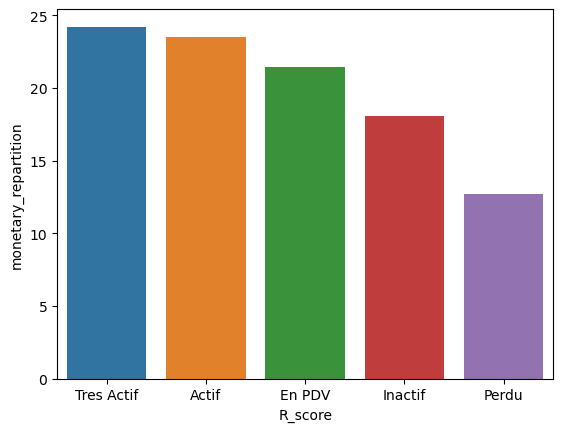

In [25]:
sns.barplot(data = Cash_per_Recency, x = 'R_score' , y = 'monetary_repartition')

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


<Axes: xlabel='F_score', ylabel='monetary_repartition'>

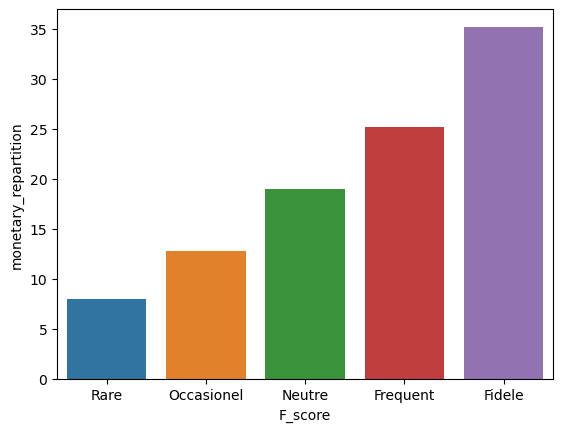

In [24]:
sns.barplot(data = Cash_per_frequency, x = 'F_score' , y = 'monetary_repartition')

Text(0.5, 1.0, 'Valeur monétaire moyenne par Récence × Fréquence')

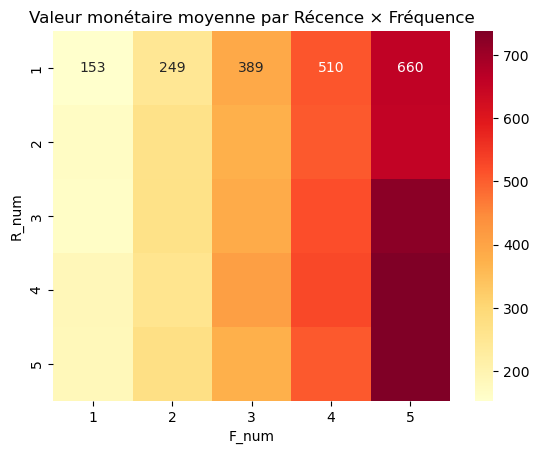

In [61]:

sns.countplot(data=rfm, x='segment', order=rfm['segment'].value_counts().index)
plt.title("Répartition des clients par segment RFM")

pivot = rfm.pivot_table(values='monetary', index='R_num', columns='F_num', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title("Valeur monétaire moyenne par Récence × Fréquence")

# Conclusion & Recommandations:

## FREQUENCY X MONETARY

#### --/ Les clients "fideles" avec une forte frequence d'achat represente ceux ayant les volumes les plus hauta,. Ces clients constituent, 35% du CA. 


#### --/ Ensuite nous avons les clients "frequents" qui eux aussi contribuent de maniere significatives aux CA avec 25% 
#### --/ Ensuite les clients "neutres" avec environ 20% du volume, ils sont la troisieme niche.
#### --/ Les clients "occasionnesls" et "Rares" ces clients porte l'activite a 20%

### L’analyse Frequency-Monetary met en évidence une forte concentration du chiffre d’affaires sur les segments à haute fréquence. Plutôt qu’une approche uniforme basée sur des réductions, une stratégie différenciée est recommandée

###  R1 (clients fidels) : Ces clients ont déjà une forte propension à acheter, l’enjeu est d’augmenter leur valeur unitaire plutôt que leur fréquence

#### --> Programme VIP (accès prioritaire, service premium)
#### --> Offres exclusives (pas forcément moins chères)
#### --> bundles produits (augmenter panier moyen)


### R2 (Clients Frequents) : transformer les fréquents en fidèles via des mécanismes d’engagement plutôt que des remises directes.

#### --> Promouvoir pour ces clients des cashbacks differe 
#### --> Programmes de fidélité progressifs (gamification)
#### --> Mettre en place un plan de rewards a chaque achat ou un bonus a partir d'un certain seuil.

### R3 (Clients neutres) : Segment à fort levier d’activation permettant une croissance du CA sans dépendre uniquement des clients existants.

#### --> Mettre en place des campagnes ciblees (emai/SMS) afin d'accroitre l'engagement de ce segment
#### --> Faire du cross selling afin d'ameiorer l'experience clien
#### --> offres de réactivation


## RECENCY X MONETARY

### --/ En ce qui concerne la recence, les clients actifs, tres actifs et en perte de vitesse constituent environ 70% du CA, les inacifs et les perdu environ 30%. La contribution au chiffre d’affaires reste relativement répartie entre les segments récents, ce qui suggère que la récence seule n’est pas discriminante sur le CA historique. En revanche, elle reste un indicateur clé pour anticiper le désengagement client.

## --> Segment Frequence X Categorie de produits.
#### Il est question de savoir quels sont les produits les plus conommes ainsi que la consommation de chaque produit par segment,

In [29]:
product_df.describe()

,total_orders,total_revenue_usd,avg_price,avg_rating,return_rate,avg_discount_pct,avg_delivery_days
count,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,168.171429,21135.674357,60.435286,3.999714,8.750000,5.582286,4.169214
std,113.141087,27013.447877,33.624582,0.095631,2.423283,0.825639,0.240506
min,38.000000,3231.830000,20.000000,3.600000,3.000000,3.310000,3.430000
25%,80.750000,7723.132500,31.132500,3.960000,7.000000,5.107500,4.047500
50%,142.500000,10362.085000,55.055000,4.010000,8.000000,5.580000,4.160000
75%,185.000000,16083.300000,80.447500,4.052500,10.000000,6.115000,4.272500
max,466.000000,124113.880000,143.340000,4.230000,17.000000,7.750000,4.860000


In [30]:
product_df.head()

,category,product_name,total_orders,total_revenue_usd,avg_price,avg_rating,return_rate,avg_discount_pct,avg_delivery_days
0,Automotive,Air Freshener,87,10543.38,73.61,3.95,7.0,4.54,4.66
1,Automotive,Car Phone Mount,86,10950.18,73.82,3.99,12.0,5.76,4.08
2,Automotive,Car Vacuum Cleaner,73,8588.32,71.15,4.11,7.0,7.53,4.38
3,Automotive,Dashcam 4K,79,9402.79,68.25,4.06,6.0,4.18,4.20
4,Automotive,Jump Starter Pack,68,8338.79,78.06,4.00,10.0,4.63,4.03


In [35]:
prod_X_cust = transac_df.groupby(['customer_id','category']).agg( Qte_cmd = ("order_id","count"),total_quantity=("quantity", "sum")).reset_index()

In [36]:
prod_X_cust

,customer_id,category,Qte_cmd,total_quantity
0,C00001,Electronics,1,1
1,C00001,Sports & Outdoors,1,5
2,C00002,Books,1,1
3,C00002,Electronics,1,2
4,C00002,Toys & Games,2,2
...,...,...,...,...
21507,C07997,Home & Kitchen,3,9
21508,C07998,Books,1,2
21509,C07999,Clothing & Apparel,1,1
21510,C07999,Home & Kitchen,1,1


In [42]:
prod_cust = prod_X_cust.merge(rfm, on='customer_id', suffixes = ("","_new_col"))
prod_cust = prod_cust[['customer_id', "category", "Qte_cmd","R_score", "F_score", "monetary"]]

In [46]:
pd.crosstab(prod_cust['F_score'], prod_cust['category'], normalize = True,margins=True)*100

category,Automotive,Beauty & Personal Care,Books,Clothing & Apparel,Electronics,Food & Grocery,Health & Wellness,Home & Kitchen,Jewelry & Accessories,Office Supplies,Pet Supplies,Sports & Outdoors,Toys & Games,Travel & Luggage,All
F_score,,,,,,,,,,,,,,,
Rare,0.348643,0.683340,0.794905,1.385273,1.594459,0.585720,0.469505,1.092414,0.306806,0.237077,0.213834,0.678691,0.409074,0.158051,8.957791
Occasionel,0.399777,0.925065,1.101711,2.129044,2.473038,0.846039,0.739122,1.743213,0.562477,0.464857,0.506694,1.190033,0.892525,0.283563,14.257159
Neutre,0.604314,1.464299,1.524730,2.844924,3.416698,1.157493,0.859985,2.240610,0.748419,0.711231,0.571774,1.329491,1.380625,0.423020,19.277612
Frequent,0.850688,1.678133,2.133693,3.635180,3.756043,1.538676,1.385273,2.993678,1.152845,0.850688,0.939011,1.710673,1.552622,0.660097,24.837300
Fidele,1.208628,2.435850,2.672927,4.560245,4.890294,2.133693,1.798996,3.830420,1.473596,1.166791,1.097062,2.491633,2.101153,0.808851,32.670138
All,3.412049,7.186687,8.227966,14.554667,16.130532,6.261621,5.252882,11.900335,4.244143,3.430643,3.328375,7.400521,6.335999,2.333581,100.000000


In [53]:
pd.crosstab(prod_cust['F_score'], prod_cust['category'], values=prod_cust['monetary'], aggfunc='sum',margins=True)*100

category,Automotive,Beauty & Personal Care,Books,Clothing & Apparel,Electronics,Food & Grocery,Health & Wellness,Home & Kitchen,Jewelry & Accessories,Office Supplies,Pet Supplies,Sports & Outdoors,Toys & Games,Travel & Luggage,All
F_score,,,,,,,,,,,,,,,
Rare,1438976.0,1941619.0,1777733.0,4972303.0,10256364.0,1356876.0,1375193.0,4539226.0,1524859.0,1421396.0,616246.0,2538339.0,1029157.0,718971.0,3.550726e+07
Occasionel,2218034.0,4241004.0,4670053.0,11876425.0,19840555.0,3529372.0,3033688.0,9770775.0,3254309.0,3028248.0,2154173.0,6276477.0,4347686.0,1809262.0,8.005006e+07
Neutre,4933966.0,10722054.0,10166837.0,23454052.0,36430945.0,7190231.0,5400116.0,19621735.0,6376429.0,6890513.0,4304251.0,9780971.0,9479185.0,4055046.0,1.588063e+08
Frequent,9062795.0,16255076.0,20861621.0,40215588.0,50459455.0,14764568.0,13391829.0,34244603.0,13346629.0,10308163.0,9098129.0,17695569.0,15999229.0,7636352.0,2.733396e+08
Fidele,18983877.0,36361826.0,39752774.0,70547804.0,83757101.0,30309078.0,27563669.0,61549495.0,23903555.0,20081198.0,15665915.0,39219211.0,31602574.0,13144243.0,5.124423e+08
All,36637648.0,69521579.0,77229018.0,151066172.0,200744420.0,57150125.0,50764495.0,129725834.0,48405781.0,41729518.0,31838714.0,75510567.0,62457831.0,27363874.0,1.060146e+09


## Conclusion & Recommandations:
### FREQUENCY X CATEGORY
#### --/ Les clients "fidèles" dominent la consommation sur l’ensemble des catégories, en particulier sur Electronics, Clothing & Apparel et Home & Kitchen. Cette surreprésentation s’explique par leur volume d’achat élevé et leur rôle central dans la génération de valeur.
#### --/ Les clients "fréquents" constituent le deuxième moteur de consommation, avec une forte contribution sur Clothing & Apparel et Home & Kitchen, et un potentiel important de bascule vers les segments à plus forte valeur.
#### --/ Les clients "neutres" présentent une consommation intermédiaire, relativement diversifiée, notamment sur Clothing, Electronics et Food & Grocery, ce qui en fait un segment clé pour les stratégies d’activation.
#### --/ Les clients "occasionnels" et "rares" ont une faible contribution globale, concentrée sur des catégories de consommation courante (Food, Beauty), avec peu d’impact sur les catégories à forte valeur comme Electronics.

##### L’analyse Frequency-Category met en évidence que certaines catégories (notamment Electronics, Clothing & Apparel et Home & Kitchen) structurent fortement la valeur client. Toutefois, cette dominance est en partie liée au volume des clients fidèles. Une stratégie efficace doit donc distinguer volume et préférence réelle afin d’optimiser les actions marketing et opérationnelles.

### Recommandations
#### R1 (clients fidèles) : Maximiser la valeur client (CLV) via les catégories à forte contribution
##### --> Mettre en avant des produits à forte valeur (notamment Electronics) via des offres premium
##### --> Proposer des bundles sur Home & Kitchen pour augmenter le panier moyen
##### --> Développer des programmes VIP (accès anticipé, services exclusifs)
##### --> Recommandations personnalisées basées sur leur historique d’achat
#### R2 (clients fréquents) : Accélérer la montée vers le segment fidèle
##### --> Pousser des catégories à forte récurrence comme Clothing & Apparel
##### --> Mettre en place des programmes de fidélité progressifs (gamification)
##### --> Offrir des incitations différées (cashback, rewards cumulés)
##### --> Activer du cross-selling vers Electronics pour augmenter la valeur
#### R3 (clients neutres) : Segment à fort potentiel d’activation
##### --> Campagnes ciblées (email / SMS) sur des catégories accessibles (Clothing, Food, Beauty)
##### --> Stratégies de cross-selling pour enrichir l’expérience client
##### --> Offres de réactivation et promotions limitées dans le temps
##### --> Mise en avant de produits du quotidien pour créer des habitudes d’achat
#### R4 (clients occasionnels & rares) : Activer et initier des habitudes de consommation
##### --> Promotions d’entrée sur des produits de consommation courante (Food, Beauty)
##### --> Offres simples et attractives (réduction immédiate, livraison offerte)
##### --> Parcours client simplifié pour réduire les frictions à l’achat
##### --> Campagnes de retargeting pour stimuler la récurrence